<a href="https://colab.research.google.com/github/fergogu27-ctrl/EDPII/blob/main/Descomposicion_canonica_parte_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Descomposición Canónica**

In [46]:
import sympy as sp                  #Nos ayuda a trabajar con matrices y fracciones exactas.
import numpy as np                  #En este caso podemos hacer las comparaciones numéricas.
import matplotlib.pyplot as plt     #Graficas y diagrama
import networkx as nx               #Representa la cadena como un grafo

##  Matriz de transición \(P\)

Tenemos los estados:

$$
(a,b,c,d,e,f,g).
$$


La matriz P de la imagen es:



$$P=\begin{pmatrix}
1/4&0&0&0&0&0&3/4\\
1/8&1/8&1/4&0&1/4&1/8&1/8\\
0&0&2/5&1/5&2/5&0&0\\
0&0&1/2&1/2&0&0&0\\
0&0&0&1/2&1/2&0&0\\
0&1/5&0&1/5&1/5&1/5&1/5\\
4/5&0&0&0&0&0&1/5
\end{pmatrix}$$

1. Escriba la matriz P de la imagen anexada y dibuje su diagrama de transicion; clasificar los estados , grupos de comunicacion cuales son recurrentes y cuales son transitorios.



In [47]:
P = sp.Matrix([                                  # Define la matriz de transición P usando fracciones exactas.
    [sp.Rational(1,4), 0, 0, 0, 0, 0, sp.Rational(3,4)],
    [sp.Rational(1,8), sp.Rational(1,8), sp.Rational(1,4), 0, sp.Rational(1,4), sp.Rational(1,8), sp.Rational(1,8)],
    [0, 0, sp.Rational(2,5), sp.Rational(1,5), sp.Rational(2,5), 0, 0],
    [0, 0, sp.Rational(1,2), sp.Rational(1,2), 0, 0, 0],
    [0, 0, 0, sp.Rational(1,2), sp.Rational(1,2), 0, 0],
    [0, sp.Rational(1,5), 0, sp.Rational(1,5), sp.Rational(1,5), sp.Rational(1,5), sp.Rational(1,5)],
    [sp.Rational(4,5), 0, 0, 0, 0, 0, sp.Rational(1,5)]
])
P

Matrix([
[1/4,   0,   0,   0,   0,   0, 3/4],
[1/8, 1/8, 1/4,   0, 1/4, 1/8, 1/8],
[  0,   0, 2/5, 1/5, 2/5,   0,   0],
[  0,   0, 1/2, 1/2,   0,   0,   0],
[  0,   0,   0, 1/2, 1/2,   0,   0],
[  0, 1/5,   0, 1/5, 1/5, 1/5, 1/5],
[4/5,   0,   0,   0,   0,   0, 1/5]])

In [48]:
Estados = ['a', 'b', 'c', 'd', 'e', 'f', 'g']       #Definimos los estados con su respectivo orden.

Ahora dibujamos su diagram de transición

# Diagrama de transiciones

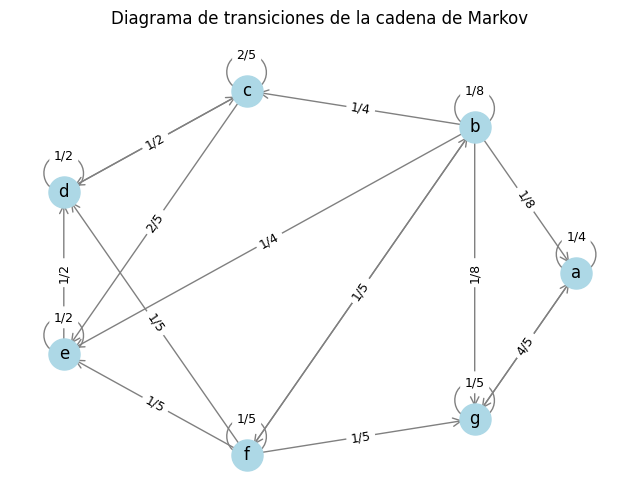

In [49]:
G = nx.DiGraph()

for estado in Estados:
    G.add_node(estado)

for i in range(P.shape[0]):                                # Recorre las filas de P.
    for j in range(P.shape[1]):                            # Recorre las columnas de P.
        if P[i, j] > 0:                                    # Si la probabilidad de transición es positiva,
            G.add_edge(Estados[i], Estados[j], weight=P[i, j])

pos = nx.circular_layout(G)

plt.figure(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray')

edge_labels = {(u, v): str(d["weight"]) for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
plt.title("Diagrama de transiciones de la cadena de Markov")
plt.axis('off')
plt.show()

Teniendo el diagrama observamos como se comportan los estados y determinamos cuantas clases existen, y checamos cada clase si es recurrente o transitorio de acuerdo a la definición, y si tiene periodo

# Clases comunicantes

Del diagrama se observa:
* [{a,g}] es una clase cerrada, porque desde el estado (a) y el estado (g) sólo se puede ir a (a) o (g).
* [{c,d,e}] es una clase cerrada, porque desde (c,d,e) sólo se puede ir a (c,d,e).

* [{b,f}] son estados transitorios, porque desde ellos se puede entrar a clases cerradas, pero una vez dentro de una clase cerrada ya no se regresa a (b) ni a (f).

Por lo tanto , la cadena no es irreducible.





2. Determine si la matriz tiene o no distribución límite.

Determinamos que la distribución limite es un unico vector $\pi$ tal que:
$$
\lim_{n\to\infty}P^n=
\begin{pmatrix}
\pi\\
\pi\\
\vdots\\
\pi
\end{pmatrix},
$$
Entonces la matriz no tiene una distribucion limite.

Tenemos que existen dos clases cerradas:
$$
\{a,g\}
\quad\text{y}\quad
\{c,d,e\}.
$$


3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.

#  Descomposición canónica de la matriz

De acuerdo con el análisis de los estados:

$$
T=\{b,f\}
$$

porque desde $(b)$ y $(f)$ se puede salir hacia alguna clase cerrada y después ya no regresar.

Las clases recurrentes cerradas son:

$$
R_1=\{a,g\}
$$

y

$$
R_2=\{c,d,e\}
$$

Por lo tanto, el nuevo orden:

$$
(b,f,a,g,c,d,e)
$$

Es decir, primero ponemos los transitorios y después las clases recurrentes cerradas.

In [50]:
N_estados = ["b", "f", "a", "g", "c", "d", "e"]       #Definimos el nuevo orden de los estados establecidos por el diagrama de transiciones.

In [51]:
N_indices = [Estados.index(s) for s in N_estados]    #Reordenamos el esatdo con su indice correspondiente
Pc = P.extract(N_indices, N_indices)
Pc                                                   #Matriz canónica

Matrix([
[1/8, 1/8, 1/8, 1/8, 1/4,   0, 1/4],
[1/5, 1/5,   0, 1/5,   0, 1/5, 1/5],
[  0,   0, 1/4, 3/4,   0,   0,   0],
[  0,   0, 4/5, 1/5,   0,   0,   0],
[  0,   0,   0,   0, 2/5, 1/5, 2/5],
[  0,   0,   0,   0, 1/2, 1/2,   0],
[  0,   0,   0,   0,   0, 1/2, 1/2]])

La matriz canónica queda de la forma:

$$
P_c =
\begin{pmatrix}
Q & A_1 & A_2\\
0 & P_1 & 0\\
0 & 0 & P_2
\end{pmatrix}
$$

donde:

- $Q$ corresponde a los estados transitorios.
- $P_1$ corresponde a la clase recurrente $R_1={a,g}$.
- $P_2$ corresponde a la clase recurrente $R_2={c,d,e}$.
- $A_1$ contiene las probabilidades de pasar de estados transitorios hacia $R_1$.
- $A_2$ contiene las probabilidades de pasar de estados transitorios hacia $R_2$.


In [52]:
Q = Pc[0:2, 0:2]    #Extramos el bloque Q donde hay 2 estadis transitorios
Q

Matrix([
[1/8, 1/8],
[1/5, 1/5]])

In [53]:
A1 = Pc[0:2, 2:4]   #Los estados transitorios hacia R_1= {a,g}.
A1

Matrix([
[1/8, 1/8],
[  0, 1/5]])

In [54]:
A2 = Pc[0:2,4:7]    #Los estados transitorios hacia R2 = {c,d,e}.
A2

Matrix([
[1/4,   0, 1/4],
[  0, 1/5, 1/5]])

In [55]:
P1 = Pc[2:4,2:4]    #La submatriz de la clase recurrente R1 = {a,g}.
P1

Matrix([
[1/4, 3/4],
[4/5, 1/5]])

In [56]:
P2 = Pc[4:7,4:7]    #La submatriz de la clase recurrente R2 = {c,d,e}..
P2

Matrix([
[2/5, 1/5, 2/5],
[1/2, 1/2,   0],
[  0, 1/2, 1/2]])

Distribuciones límite de las submatrices recurrentes:

Ahora calculamos la distribución estacionaria de cada clase recurrente cerrada.

Para $R_1={a,g}$, buscamos:

$$
\pi_1 P_1 = \pi_1,
\qquad
\pi_{1,a}+\pi_{1,g}=1.
$$

Para $R_2={c,d,e}$,  buscamos:

$$
\pi_2 P_2 = \pi_2,
\qquad
\pi_{2,c}+\pi_{2,d}+\pi_{2,e}=1.
$$

In [57]:
def distribucion_estacionaria(Pb):            #Definimos la funcion para calcular la distribucion estacionaria de la matriz por bloques
    n = Pb.rows                               #Numero de estados de cada bloque
    variables = sp.symbols(f"p0:{n}")
    pi = sp.Matrix(1, n, variables)           #Creamos un vector fila
    ecuaciones = list(pi * Pb - pi)           #Ecuaciones pi *Pb = pi
    ecuaciones.append(sum(variables)-1)       #Normalizamos la ecuacion
    solucion = sp.solve(ecuaciones, variables, dict=True)[0]    #Resolvemos el sistema de ecuaciones
    resultado = sp.Matrix([[sp.simplify(solucion[v])for v in variables]])     #Distribucion estacionaria en vector fila.
    return resultado

In [58]:
pi1 = distribucion_estacionaria(P1)     #Calculamos la distribución estacionaria de la clase R1 = {a,g}.
pi1

Matrix([[16/31, 15/31]])

In [59]:
pi2 = distribucion_estacionaria(P2)     # Calculamos la distribución estacionaria de la clase R2 = {c,d,e}.
pi2

Matrix([[1/3, 2/5, 4/15]])

Por lo tanto:

$$
\pi_1=
\left(
\frac{16}{31},
\frac{15}{31}
\right)
$$

en el orden $(a,g)$, y

$$
\pi_2=
\left(
\frac{1}{3},
\frac{2}{5},
\frac{4}{15}
\right)
$$

en el orden $(c,d,e)$.

Ahora formamos los límites de las potencias de las submatrices:

$$
\lim_{n\to\infty}P_1^n
=
\begin{pmatrix}
\pi_1\\
\pi_1
\end{pmatrix}
$$

y

$$
\lim_{n\to\infty}P_2^n
=
\begin{pmatrix}
\pi_2\\
\pi_2\\
\pi_2
\end{pmatrix}.
$$


In [60]:
L1 = sp.ones(P1.rows, 1) * pi1
L1

Matrix([
[16/31, 15/31],
[16/31, 15/31]])

In [61]:
L2 = sp.ones(P2.rows, 1) * pi2
L2

Matrix([
[1/3, 2/5, 4/15],
[1/3, 2/5, 4/15],
[1/3, 2/5, 4/15]])

## Límite de la potencia n-ésima de la matriz canónica

Para los estados transitorios usamos la matriz fundamental:

$$
N=(I-Q)^{-1}.
$$

Después:

$$
N A_1
$$

nos ayuda a calcular la probabilidad de llegar desde los transitorios a la clase $R_1$, y

$$
N A_2
$$

nos ayuda a calcular la probabilidad de llegar desde los transitorios a la clase $R_2$.

Como las clases $R_1$ y $R_2$ son cerradas, una vez que la cadena entra a una de ellas, se queda ahí.

In [62]:
I = sp.eye(Q.rows)      #Matriz identidad
N = (I - Q)**-1         #Matriz fundamental
N

Matrix([
[32/27,  5/27],
[ 8/27, 35/27]])

In [63]:
NA1 = N * A1
NA1

Matrix([
[4/27, 5/27],
[1/27, 8/27]])

In [64]:
prob_R1 = NA1 * sp.ones(A1.cols, 1)  #probabilidad de terminar en la clase R1.
prob_R1

Matrix([
[1/3],
[1/3]])

In [65]:
NA2 = N * A2
NA2

Matrix([
[8/27, 1/27, 1/3],
[2/27, 7/27, 1/3]])

In [66]:
prob_R2 = NA2 * sp.ones(A2.cols, 1)     #probabilidad de terminar en la clase R2.
prob_R2

Matrix([
[2/3],
[2/3]])

La interpretación es:

$$
P(\text{terminar en }R_1\mid b)=\frac{1}{3},
\qquad
P(\text{terminar en }R_1\mid f)=\frac{1}{3}.
$$

También:

$$
P(\text{terminar en }R_2\mid b)=\frac{2}{3},
\qquad
P(\text{terminar en }R_2\mid f)=\frac{2}{3}.
$$

Por eso, desde $b$ o desde $f$, el renglón límite se forma así:

$$
\frac{1}{3}\pi_1
$$

para las columnas de $R_1$, y

$$
\frac{2}{3}\pi_2
$$

para las columnas de $R_2$.


In [67]:
lim_R1 = sp.simplify(prob_R1 * pi1)   ## Calculamos la parte límite que corresponde a R1 desde los estados transitorios.
lim_R1

Matrix([
[16/93, 5/31],
[16/93, 5/31]])

In [68]:
lim_R2 = sp.simplify(prob_R2 * pi2)   ## Calculamos la parte límite que corresponde a R2 desde los estados transitorios.
lim_R2

Matrix([
[2/9, 4/15, 8/45],
[2/9, 4/15, 8/45]])

Por lo tanto, en el orden canónico:
$$
(b,f,a,g,c,d,e)
$$

el límite tiene la forma:

$$
\lim_{n\to\infty} P_c^n
=
\begin{pmatrix}
0 & 0 & \frac{1}{3}\pi_1 & \frac{2}{3}\pi_2\\
0 & 0 & \pi_1 & 0\\
0 & 0 & 0 & \pi_2
\end{pmatrix}
$$

escrito por bloques.

In [71]:
l = sp.zeros(7,7)
l[0:2,2:4] = lim_R1
l[0:2,4:7] = lim_R2
l[2:4,2:4] = L1
l[4:7,4:7] = L2
l

Matrix([
[0, 0, 16/93,  5/31, 2/9, 4/15, 8/45],
[0, 0, 16/93,  5/31, 2/9, 4/15, 8/45],
[0, 0, 16/31, 15/31,   0,    0,    0],
[0, 0, 16/31, 15/31,   0,    0,    0],
[0, 0,     0,     0, 1/3,  2/5, 4/15],
[0, 0,     0,     0, 1/3,  2/5, 4/15],
[0, 0,     0,     0, 1/3,  2/5, 4/15]])

Así se ve la comparación:

- La parte correspondiente a $R_1$ coincide con el límite de $P_1^n$.
- La parte correspondiente a $R_2$ coincide con el límite de $P_2^n$.
- Los estados transitorios $b$ y $f$ no conservan probabilidad en el límite, por eso las columnas de $b$ y $f$ son cero.